<a href="https://colab.research.google.com/github/dang710206/btap-AI---week-2/blob/main/bt13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 12.6 MB/s eta 0:00:00


Mức chiết khấu đề xuất: 15.00%


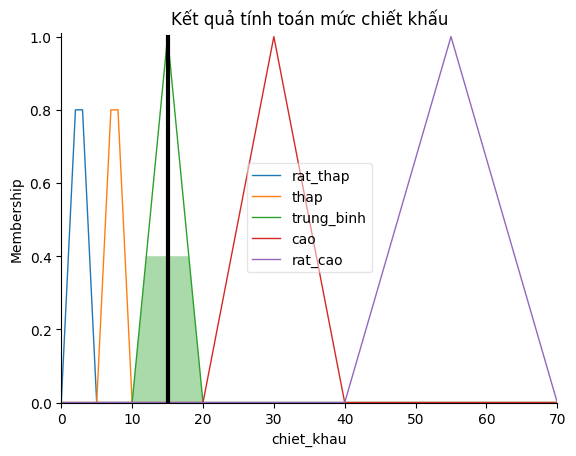

In [7]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np
import matplotlib.pyplot as plt

nhu_cau_san_pham = ctrl.Antecedent(np.arange(0, 101, 1), 'nhu_cau_san_pham')
ap_luc_canh_tranh = ctrl.Antecedent(np.arange(0, 101, 1), 'ap_luc_canh_tranh')
danh_tieng_cua_hang = ctrl.Antecedent(np.arange(1, 6, 0.1), 'danh_tieng_cua_hang')
bien_loi_nhuan = ctrl.Antecedent(np.arange(0, 101, 1), 'bien_loi_nhuan')
nhu_cau_mua_vu = ctrl.Antecedent(np.arange(0, 101, 1), 'nhu_cau_mua_vu')

chiet_khau = ctrl.Consequent(np.arange(0, 71, 1), 'chiet_khau')

nhu_cau_san_pham['thap'] = fuzz.trimf(nhu_cau_san_pham.universe, [0, 0, 40])
nhu_cau_san_pham['trung_binh'] = fuzz.trimf(nhu_cau_san_pham.universe, [30, 50, 70])
nhu_cau_san_pham['cao'] = fuzz.trimf(nhu_cau_san_pham.universe, [60, 100, 100])

ap_luc_canh_tranh['thap'] = fuzz.trimf(ap_luc_canh_tranh.universe, [0, 0, 35])
ap_luc_canh_tranh['trung_binh'] = fuzz.trimf(ap_luc_canh_tranh.universe, [25, 50, 75])
ap_luc_canh_tranh['cao'] = fuzz.trimf(ap_luc_canh_tranh.universe, [65, 100, 100])

danh_tieng_cua_hang['thap'] = fuzz.trimf(danh_tieng_cua_hang.universe, [1, 2, 4])
danh_tieng_cua_hang['trung_binh'] = fuzz.trimf(danh_tieng_cua_hang.universe, [4, 4.25, 4.5])
danh_tieng_cua_hang['cao'] = fuzz.trimf(danh_tieng_cua_hang.universe, [4.5, 4.75, 5])

bien_loi_nhuan['thap'] = fuzz.trimf(bien_loi_nhuan.universe, [0, 0, 35])
bien_loi_nhuan['trung_binh'] = fuzz.trimf(bien_loi_nhuan.universe, [25, 50, 75])
bien_loi_nhuan['cao'] = fuzz.trimf(bien_loi_nhuan.universe, [65, 100, 100])

nhu_cau_mua_vu['khong'] = fuzz.trimf(nhu_cau_mua_vu.universe, [0, 0, 30])
nhu_cau_mua_vu['trung_binh'] = fuzz.trimf(nhu_cau_mua_vu.universe, [20, 50, 80])
nhu_cau_mua_vu['cao'] = fuzz.trimf(nhu_cau_mua_vu.universe, [60, 100, 100])

chiet_khau['rat_thap'] = fuzz.trimf(chiet_khau.universe, [0, 2.5, 5])
chiet_khau['thap'] = fuzz.trimf(chiet_khau.universe, [5, 7.5, 10])
chiet_khau['trung_binh'] = fuzz.trimf(chiet_khau.universe, [10, 15, 20])
chiet_khau['cao'] = fuzz.trimf(chiet_khau.universe, [20, 30, 40])
chiet_khau['rat_cao'] = fuzz.trimf(chiet_khau.universe, [40, 55, 70])

rule1 = ctrl.Rule(nhu_cau_san_pham['cao'] & ap_luc_canh_tranh['thap'] & bien_loi_nhuan['thap'],
                 chiet_khau['rat_thap'])

rule2 = ctrl.Rule(nhu_cau_san_pham['thap'] & ap_luc_canh_tranh['cao'] & bien_loi_nhuan['cao'],
                 chiet_khau['cao'])

rule3 = ctrl.Rule(danh_tieng_cua_hang['cao'] & bien_loi_nhuan['trung_binh'] & nhu_cau_mua_vu['cao'],
                 chiet_khau['trung_binh'])

rule4 = ctrl.Rule(ap_luc_canh_tranh['cao'] & nhu_cau_mua_vu['cao'] & bien_loi_nhuan['cao'],
                 chiet_khau['rat_cao'])

rule5 = ctrl.Rule(danh_tieng_cua_hang['thap'] & nhu_cau_san_pham['trung_binh'] & bien_loi_nhuan['thap'],
                 chiet_khau['trung_binh'])

rule6 = ctrl.Rule(nhu_cau_san_pham['cao'] & nhu_cau_mua_vu['khong'] & ap_luc_canh_tranh['thap'],
                 chiet_khau['rat_thap'])

rule7 = ctrl.Rule(bien_loi_nhuan['cao'] & ap_luc_canh_tranh['trung_binh'] & nhu_cau_mua_vu['trung_binh'],
                 chiet_khau['trung_binh'])

he_thong_chiet_khau = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
mo_phong = ctrl.ControlSystemSimulation(he_thong_chiet_khau)

mo_phong.input['nhu_cau_san_pham'] = 83
mo_phong.input['ap_luc_canh_tranh'] = 49
mo_phong.input['danh_tieng_cua_hang'] = 4.3
mo_phong.input['bien_loi_nhuan'] = 79
mo_phong.input['nhu_cau_mua_vu'] = 48

mo_phong.compute()

print(f"Mức chiết khấu đề xuất: {mo_phong.output['chiet_khau']:.2f}%")

chiet_khau.view(sim=mo_phong)
plt.title('Kết quả tính toán mức chiết khấu')
plt.show()